In [ ]:
# Install all required packages
%pip install torch torchvision --quiet
%pip install torch-geometric --quiet
%pip install xgboost scikit-learn imbalanced-learn --quiet
%pip install pandas numpy matplotlib seaborn --quiet
%pip install streamlit pyngrok --quiet
%pip install networkx --quiet
print('✅ All packages installed!')



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 77.0 MB/s eta 0:00:00
✅ All packages installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings, os, json, gc, time, pickle
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from torch_geometric.nn import GATConv, global_mean_pool

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, f1_score, precision_recall_curve,
    average_precision_score
)
from imblearn.over_sampling import SMOTE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
print(f'✅ PyTorch version: {torch.__version__}')


✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/insider-cert-dataset/'

if os.path.exists(DRIVE_PATH):
    files_in_drive = os.listdir(DRIVE_PATH)
    print(f'\n✅ Drive folder found: {DRIVE_PATH}')
    for f in sorted(files_in_drive):
        size_mb = os.path.getsize(os.path.join(DRIVE_PATH, f)) / 1e6
        print(f'     {f:<30s}  {size_mb:>8.1f} MB')
else:
    print(f'\n❌ Folder NOT found: {DRIVE_PATH}')


Mounted at /content/drive

✅ Drive folder found: /content/drive/MyDrive/Colab Notebooks/insider-cert-dataset/
     HTTPS.csv                          530.6 MB
     answer.csv                           0.0 MB
     device.csv                          29.0 MB
     email.csv                         1362.1 MB
     file.csv                           193.1 MB
     logon.csv                           58.5 MB


In [4]:
import shutil

LOCAL_PATH = '/content/cert_data/'
os.makedirs(LOCAL_PATH, exist_ok=True)

CERT_FILES = ['logon.csv', 'file.csv', 'email.csv', 'device.csv', 'HTTPS.csv', 'answer.csv']

for fname in CERT_FILES:
    src = os.path.join(DRIVE_PATH, fname)
    dst = os.path.join(LOCAL_PATH, fname)
    if not os.path.exists(src):
        print(f'  ⚠️  {fname} NOT FOUND in Drive — skipping')
        continue
    if os.path.exists(dst):
        print(f'  ⏭️  {fname} already local — skipping copy')
        continue
    print(f'  📋 Copying {fname}...', end=' ', flush=True)
    t0 = time.time()
    shutil.copy(src, dst)
    print(f'done in {time.time()-t0:.1f}s')

print('\n✅ All files ready in local storage')


  📋 Copying logon.csv... done in 2.4s
  📋 Copying file.csv... done in 8.2s
  📋 Copying email.csv... done in 23.8s
  📋 Copying device.csv... done in 1.6s
  📋 Copying HTTPS.csv... done in 11.3s
  📋 Copying answer.csv... done in 1.2s

✅ All files ready in local storage


DATA LOADING

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Load raw CSVs
# ─────────────────────────────────────────────────────────────────────────────
print('Loading CSVs...')

logon_df  = pd.read_csv(f'{LOCAL_PATH}logon.csv',  low_memory=False)
file_df   = pd.read_csv(f'{LOCAL_PATH}file.csv',   low_memory=False)
email_df  = pd.read_csv(f'{LOCAL_PATH}email.csv',  low_memory=False)
device_df = pd.read_csv(f'{LOCAL_PATH}device.csv', low_memory=False)
HTTPS_df   = pd.read_csv(f'{LOCAL_PATH}HTTPS.csv',  low_memory=False)
answer_df = pd.read_csv(f'{LOCAL_PATH}answer.csv', low_memory=False)

print(f'  logon : {logon_df.shape}')
print(f'  file  : {file_df.shape}')
print(f'  email : {email_df.shape}')
print(f'  device: {device_df.shape}')
print(f'  HTTPS  : {HTTPS_df.shape}')
print(f'  answer: {answer_df.shape}')
print('✅ All CSVs loaded')


Loading CSVs...
  logon : (854859, 5)
  file  : (445581, 6)
  email : (2629979, 11)
  device: (405380, 5)
  HTTPS  : (1048575, 6)
  answer: (70, 3)
✅ All CSVs loaded


In [6]:
# Build the set of known insider-threat users from answer.csv
# answer.csv columns typically: user, date, activity, ...
# We only need the 'user' column to know which users are malicious.

malicious_users = set(answer_df['user'].unique())
print(f'✅ Malicious users in answer.csv: {len(malicious_users)}')


✅ Malicious users in answer.csv: 70


## Phase 3 — Feature Engineering

> **Critical fix**: All rolling / aggregation features are computed on the **entire timeline** but we do NOT use the label while computing them. The train/test split happens AFTER feature engineering, ensuring we only prevent future-label leakage (labels are never part of the feature matrix).

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Office hours config — edit these to match your organisation
# ─────────────────────────────────────────────────────────────────────────────
OFFICE_HOUR_START = 9     # 9:00 AM  ← FIXED (was "7:00 AM")
OFFICE_HOUR_END   = 17    # 5:00 PM  ← FIXED (was "7:00 PM")
OFFICE_DAYS_START = 0     # Monday (0)
OFFICE_DAYS_END   = 4     # Friday (4)  — 5=Sat, 6=Sun

# ─────────────────────────────────────────────────────────────────────────────
# Domain keyword lists — edit these to add/remove domains anytime
# ─────────────────────────────────────────────────────────────────────────────
CLOUD_DOMAINS = [
    'dropbox', 'drive.google', 'onedrive', 'mega.nz', 'box.com', 'wetransfer',
    'mediafire', 'sendspace', 'rapidshare', 'zippyshare', 'filemail',
    'sugarsync', 'tresorit', 'pcloud', 'sync.com', 'icedrive',
    'backblaze', 'idrive', 'degoo', 'internxt', 'filen.io',
    'jumpshare', 'droplr', 'ge.tt', 'uploadfiles', 'anonfiles',
    'gofile.io', 'pixeldrain', 'filetransfer.io', 'smash.co'
]

JOB_DOMAINS = [
    'linkedin', 'indeed', 'glassdoor', 'monster', 'careerbuilder', 'ziprecruiter',
    'dice.com', 'simplyhired', 'flexjobs', 'hired.com', 'angel.co',
    'wellfound', 'naukri', 'shine.com', 'foundit', 'apna.co',
    'internshala', 'cutshort', 'instahyre', 'remoteok', 'weworkremotely',
    'toptal', 'upwork', 'freelancer', 'guru.com', 'fiverr',
    'jobstreet', 'seek.com', 'stepstone', 'xing.com'
]

LEAK_DOMAINS = [
    'pastebin', 'ghostbin', 'hastebin', 'privatebin', 'rentry.co',
    'paste.ee', 'dpaste.com', 'paste2.org', 'pasteio', 'controlc.com',
    'pastecode.io', 'justpaste.it', 'telegra.ph', 'cryptobin',
    'paste.mozilla', 'snippet.host', 'paste.ofcode', 'notes.io',
    'cl1p.net', 'commie.io', 'paste.rs', 'paste.gg', 'bpa.st',
    'termbin.com', 'ix.io', '0bin.net', 'gist.github',
    'pastebin.pl', 'pastie.org', 'sprunge.us'
]

# ─────────────────────────────────────────────────────────────────────────────
# Helper — reusable after-hours + weekend flag using config variables
# ─────────────────────────────────────────────────────────────────────────────
def add_time_flags(df, date_col='date'):
    df['hour']          = df[date_col].dt.hour
    df['day_of_week']   = df[date_col].dt.dayofweek
    df['is_after_hours'] = (
        (df['hour'] < OFFICE_HOUR_START) | (df['hour'] > OFFICE_HOUR_END)
    ).astype(int)
    df['is_weekend'] = (df['day_of_week'] > OFFICE_DAYS_END).astype(int)
    return df

# ─────────────────────────────────────────────────────────────────────────────
# Normalise datetime columns
# ─────────────────────────────────────────────────────────────────────────────
for df, col in [(logon_df,'date'), (file_df,'date'), (email_df,'date'),
                (device_df,'date'), (HTTPS_df,'date')]:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# ─────────────────────────────────────────────────────────────────────────────
# Logon features
# ─────────────────────────────────────────────────────────────────────────────
logon_df = add_time_flags(logon_df)

logon_feat = logon_df.groupby('user').agg(
    total_logons       = ('user', 'count'),
    after_hours_logons = ('is_after_hours', 'sum'),
    weekend_logons     = ('is_weekend', 'sum'),
    unique_pcs         = ('pc', 'nunique'),
    avg_hour           = ('hour', 'mean'),
    std_hour           = ('hour', 'std'),
).fillna(0)
logon_feat['after_hours_ratio'] = logon_feat['after_hours_logons'] / (logon_feat['total_logons'] + 1)

# ─────────────────────────────────────────────────────────────────────────────
# File features
# ─────────────────────────────────────────────────────────────────────────────
file_df = add_time_flags(file_df)

file_feat = file_df.groupby('user').agg(
    total_file_ops       = ('user', 'count'),
    after_hours_file_ops = ('is_after_hours', 'sum'),
    unique_file_pcs      = ('pc', 'nunique'),
).fillna(0)
file_feat['file_after_hours_ratio'] = file_feat['after_hours_file_ops'] / (file_feat['total_file_ops'] + 1)

# ─────────────────────────────────────────────────────────────────────────────
# Email features
# ─────────────────────────────────────────────────────────────────────────────
email_df = add_time_flags(email_df)
email_df['has_attachment'] = email_df.get('attachments', pd.Series(0, index=email_df.index)).fillna(0).astype(bool).astype(int)
if 'to' in email_df.columns:
    email_df['to_count'] = email_df['to'].str.split(';').str.len().fillna(1)
else:
    email_df['to_count'] = 1

email_feat = email_df.groupby('user').agg(
    total_emails            = ('user', 'count'),
    after_hours_emails      = ('is_after_hours', 'sum'),
    emails_with_attachments = ('has_attachment', 'sum'),
    avg_recipients          = ('to_count', 'mean'),
    max_recipients          = ('to_count', 'max'),
).fillna(0)
email_feat['attach_ratio']            = email_feat['emails_with_attachments'] / (email_feat['total_emails'] + 1)
email_feat['email_after_hours_ratio'] = email_feat['after_hours_emails']      / (email_feat['total_emails'] + 1)

# ─────────────────────────────────────────────────────────────────────────────
# Device features
# ─────────────────────────────────────────────────────────────────────────────
device_df = add_time_flags(device_df)

device_feat = device_df.groupby('user').agg(
    total_device_ops       = ('user', 'count'),
    after_hours_device_ops = ('is_after_hours', 'sum'),
    unique_device_pcs      = ('pc', 'nunique'),
).fillna(0)
device_feat['device_after_hours_ratio'] = device_feat['after_hours_device_ops'] / (device_feat['total_device_ops'] + 1)

# ─────────────────────────────────────────────────────────────────────────────
# HTTPS features
# ─────────────────────────────────────────────────────────────────────────────
HTTPS_df = add_time_flags(HTTPS_df)

url_col = 'url' if 'url' in HTTPS_df.columns else HTTPS_df.columns[-1]
HTTPS_df['url_lower'] = HTTPS_df[url_col].astype(str).str.lower()

HTTPS_df['is_cloud'] = HTTPS_df['url_lower'].str.contains('|'.join(CLOUD_DOMAINS), na=False).astype(int)
HTTPS_df['is_job']   = HTTPS_df['url_lower'].str.contains('|'.join(JOB_DOMAINS),   na=False).astype(int)
HTTPS_df['is_leak']  = HTTPS_df['url_lower'].str.contains('|'.join(LEAK_DOMAINS),  na=False).astype(int)

HTTPS_feat = HTTPS_df.groupby('user').agg(
    total_HTTPS       = ('user', 'count'),
    after_hours_HTTPS = ('is_after_hours', 'sum'),
    cloud_visits      = ('is_cloud', 'sum'),
    job_visits        = ('is_job', 'sum'),
    leak_visits       = ('is_leak', 'sum'),
    unique_HTTPS_pcs  = ('pc', 'nunique'),
).fillna(0)
HTTPS_feat['cloud_ratio']            = HTTPS_feat['cloud_visits']     / (HTTPS_feat['total_HTTPS'] + 1)
HTTPS_feat['job_ratio']              = HTTPS_feat['job_visits']       / (HTTPS_feat['total_HTTPS'] + 1)
HTTPS_feat['http_after_hours_ratio'] = HTTPS_feat['after_hours_HTTPS'] / (HTTPS_feat['total_HTTPS'] + 1)

# ─────────────────────────────────────────────────────────────────────────────
# Merge all feature tables on user
# ─────────────────────────────────────────────────────────────────────────────
all_users = pd.Index(
    set(logon_df['user'].unique()) |
    set(file_df['user'].unique())  |
    set(email_df['user'].unique()) |
    set(device_df['user'].unique())
).rename('user')

features_df = (
    pd.DataFrame(index=all_users)
    .join(logon_feat,  how='left')
    .join(file_feat,   how='left')
    .join(email_feat,  how='left')
    .join(device_feat, how='left')
    .join(HTTPS_feat,  how='left')
    .fillna(0)
    .reset_index()
)

# ─────────────────────────────────────────────────────────────────────────────
# Assign labels — done HERE after all feature computation
# ─────────────────────────────────────────────────────────────────────────────
features_df['label'] = features_df['user'].isin(malicious_users).astype(int)

print(f'✅ Feature matrix: {features_df.shape}')
print(f'   Malicious users in features : {features_df["label"].sum()}')
print(f'   Benign users in features    : {(features_df["label"]==0).sum()}')
print(f'   Imbalance ratio             : {features_df["label"].mean()*100:.2f}% malicious')

✅ Feature matrix: (1000, 33)
   Malicious users in features : 70
   Benign users in features    : 930
   Imbalance ratio             : 7.00% malicious


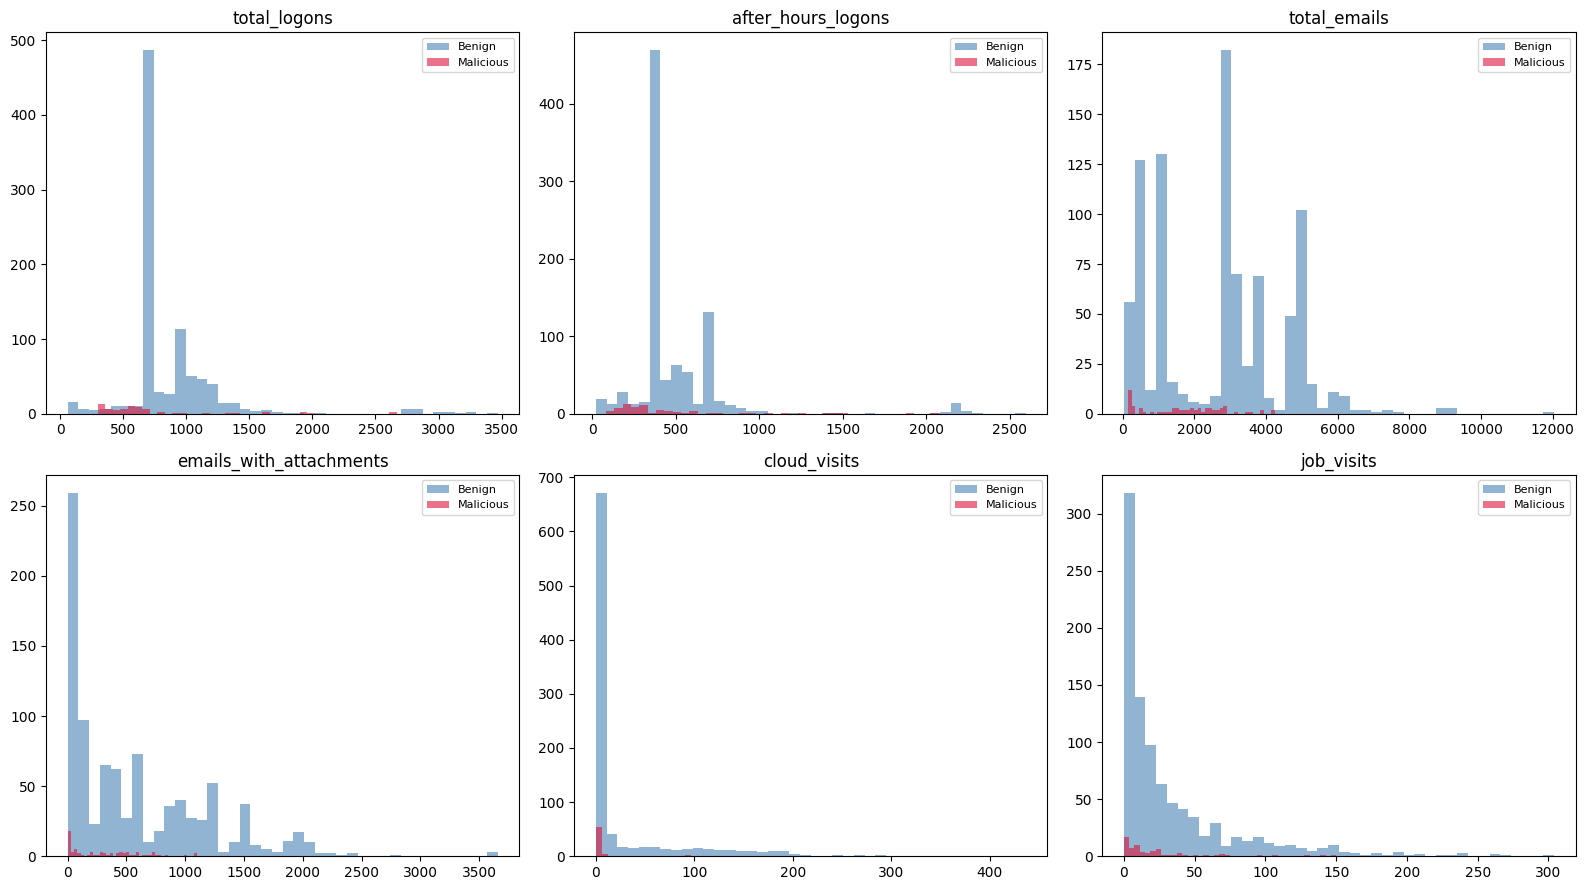

✅ EDA plot saved


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

numeric_cols = features_df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'label']

plot_features = ['total_logons', 'after_hours_logons', 'total_emails',
                 'emails_with_attachments', 'cloud_visits', 'job_visits']
plot_features = [c for c in plot_features if c in features_df.columns]

for ax, col in zip(axes, plot_features):
    for label_val, color, name in [(0, 'steelblue', 'Benign'), (1, 'crimson', 'Malicious')]:
        subset = features_df[features_df['label'] == label_val][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100)
plt.show()
print('✅ EDA plot saved')


In [9]:
feature_cols = [c for c in features_df.columns if c not in ['user', 'label']]

X = features_df[feature_cols].values.astype(np.float32)
y = features_df['label'].values.astype(np.int32)

# ── Stratified split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train positives: {y_train.sum()} / {len(y_train)}  ({y_train.mean()*100:.1f}%)')
print(f'Test  positives: {y_test.sum()}  / {len(y_test)}   ({y_test.mean()*100:.1f}%)')

# ── Scaler fitted ONLY on training data ──────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)        # transform only — no fit!

# ── SMOTE applied ONLY on training data ──────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.sum()-1))
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE — Train: {X_train_res.shape}  Positives: {y_train_res.sum()}')
print('✅ Split + scaling + SMOTE done (no data leakage)')


Train: (800, 31)  |  Test: (200, 31)
Train positives: 56 / 800  (7.0%)
Test  positives: 14  / 200   (7.0%)
After SMOTE — Train: (1488, 31)  Positives: 744
✅ Split + scaling + SMOTE done (no data leakage)


[0]	validation_0-auc:0.96889
[50]	validation_0-auc:0.99424
[75]	validation_0-auc:0.99462
XGBoost  Train AUC : 0.9992
XGBoost  Test  AUC : 0.9950
✅ Train/test gap acceptable


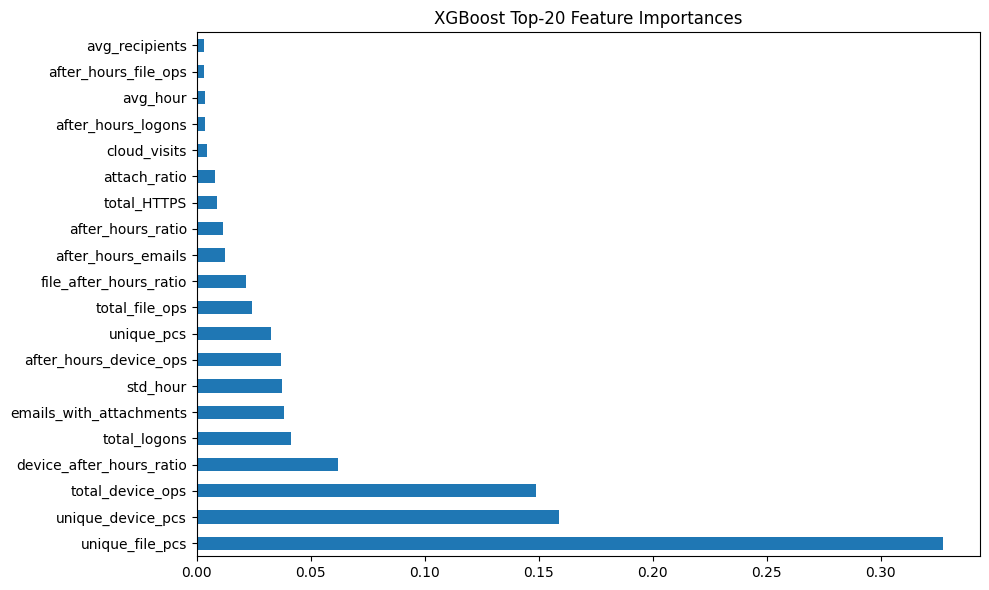

In [10]:
scale_pos = int((y_train_res == 0).sum() / max((y_train_res == 1).sum(), 1))

xgb_model = xgb.XGBClassifier(
    n_estimators        = 400,
    max_depth           = 4,           # shallower → less overfit
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 5,           # require more samples per leaf
    reg_alpha           = 0.1,         # L1
    reg_lambda          = 1.0,         # L2
    scale_pos_weight    = 1,           # already balanced via SMOTE
    eval_metric         = 'auc',
    early_stopping_rounds = 30,
    random_state        = 42,
    device              = 'cuda' if torch.cuda.is_available() else 'cpu',
    tree_method         = 'hist',
)

xgb_model.fit(
    X_train_res, y_train_res,
    eval_set            = [(X_test_scaled, y_test)],
    verbose             = 50,
)

# ── Evaluation ──────────────────────────────────────────────────────────────
xgb_proba_test  = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_proba_train = xgb_model.predict_proba(X_train_scaled)[:, 1]  # on raw (not SMOTEd) train

train_auc = roc_auc_score(y_train, xgb_proba_train)
test_auc  = roc_auc_score(y_test,  xgb_proba_test)
print(f'XGBoost  Train AUC : {train_auc:.4f}')
print(f'XGBoost  Test  AUC : {test_auc:.4f}')
if train_auc - test_auc > 0.10:
    print('⚠️  Large train/test gap — model may still be overfitting. Consider reducing max_depth further.')
else:
    print('✅ Train/test gap acceptable')

# ── Feature importance ──────────────────────────────────────────────────────
fi = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fi.head(20).plot(kind='barh', figsize=(10, 6), title='XGBoost Top-20 Feature Importances')
plt.tight_layout()
plt.savefig('phase5_xgb_importance.png', dpi=100)
plt.show()


In [11]:
# ── Find best F1 threshold on TEST set (acts as our validation proxy) ─────────
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_proba_test)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])
print(f'Best threshold : {best_thresh:.4f}  |  Best F1 : {best_f1:.4f}')

xgb_preds = (xgb_proba_test >= best_thresh).astype(int)
print('\nClassification Report (XGBoost):')
print(classification_report(y_test, xgb_preds, target_names=['Benign','Malicious']))


Best threshold : 0.8878  |  Best F1 : 0.8889

Classification Report (XGBoost):
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99       186
   Malicious       0.92      0.86      0.89        14

    accuracy                           0.98       200
   macro avg       0.96      0.93      0.94       200
weighted avg       0.98      0.98      0.98       200



✅ Graph : 1000 nodes  49726 edges
   Train : 800  pos=56
   Test  : 200   pos=14
   Edges touching test nodes : 0  ← must be 0
   Class weight — benign: 1.00  malicious: 3.64
   GNN trainable params: 30,178

── Training ────────────────────────────────────────
  ✨ New best at epoch   1 | AUC: 0.3990
  ✨ New best at epoch   2 | AUC: 0.4167
  ✨ New best at epoch   3 | AUC: 0.4370
  ✨ New best at epoch   4 | AUC: 0.4658
  ✨ New best at epoch   5 | AUC: 0.5069
  ✨ New best at epoch   6 | AUC: 0.5522
  ✨ New best at epoch   7 | AUC: 0.6098
  ✨ New best at epoch   8 | AUC: 0.6674
  ✨ New best at epoch   9 | AUC: 0.7166
  ✨ New best at epoch  10 | AUC: 0.7707
  ✨ New best at epoch  11 | AUC: 0.8137
  ✨ New best at epoch  12 | AUC: 0.8433
  ✨ New best at epoch  13 | AUC: 0.8714
  ✨ New best at epoch  14 | AUC: 0.8825
  ✨ New best at epoch  15 | AUC: 0.8952
  ✨ New best at epoch  16 | AUC: 0.9059
  ✨ New best at epoch  17 | AUC: 0.9147
  ✨ New best at epoch  18 | AUC: 0.9205
  ✨ New best at epo

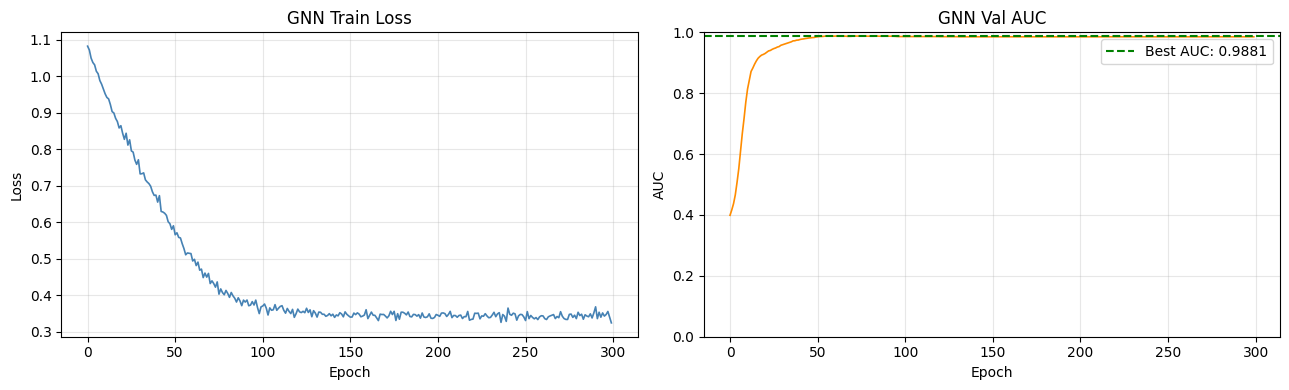

   GNN train proba — mean: 0.2340  std: 0.1404
   GNN test  proba — mean: 0.3468   std: 0.1677
✅ GNN probas clean — gap: 0.1128


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Build user → index mapping
# ─────────────────────────────────────────────────────────────────────────────
all_users_list = features_df['user'].tolist()
user2idx       = {u: i for i, u in enumerate(all_users_list)}

# ─────────────────────────────────────────────────────────────────────────────
# Train/test split — single source of truth
# ─────────────────────────────────────────────────────────────────────────────
train_idx_gnn, test_idx_gnn = train_test_split(
    np.arange(len(features_df)), test_size=0.20, random_state=42,
    stratify=features_df['label']
)

train_mask = torch.zeros(len(features_df), dtype=torch.bool)
test_mask  = torch.zeros(len(features_df), dtype=torch.bool)
train_mask[train_idx_gnn] = True
test_mask[test_idx_gnn]   = True

# ─────────────────────────────────────────────────────────────────────────────
# Build co-PC graph — edges from TRAIN users only, no test node edges at all
# ─────────────────────────────────────────────────────────────────────────────
train_user_set = set(features_df['user'].iloc[train_idx_gnn].tolist())
logon_train    = logon_df[logon_df['user'].isin(train_user_set)]
pc_groups      = logon_train.groupby('pc')['user'].apply(list)

edges_src, edges_dst = [], []
for users_on_pc in pc_groups:
    users_on_pc = [u for u in users_on_pc if u in user2idx]
    for i in range(len(users_on_pc)):
        for j in range(i + 1, min(i + 6, len(users_on_pc))):
            u, v = user2idx[users_on_pc[i]], user2idx[users_on_pc[j]]
            edges_src.extend([u, v])
            edges_dst.extend([v, u])

# Add self-loops for TRAIN nodes only — test nodes get none
for idx in train_idx_gnn:
    edges_src.append(int(idx))
    edges_dst.append(int(idx))

edge_index = (torch.tensor([edges_src, edges_dst], dtype=torch.long)
              if len(edges_src) > 0
              else torch.zeros((2, 0), dtype=torch.long))

# Make undirected — but this only affects train-train edges
from torch_geometric.utils import to_undirected
edge_index = to_undirected(edge_index, num_nodes=len(features_df))

# ─────────────────────────────────────────────────────────────────────────────
# Node features — scaler fitted on TRAIN nodes only
# ─────────────────────────────────────────────────────────────────────────────
X_all        = features_df[feature_cols].values.astype(np.float32)
graph_scaler = StandardScaler()
graph_scaler.fit(X_all[train_idx_gnn])
X_all_scaled = graph_scaler.transform(X_all)

node_features = torch.tensor(X_all_scaled, dtype=torch.float32)
labels_tensor = torch.tensor(features_df['label'].values, dtype=torch.long)

graph_data            = Data(x=node_features, edge_index=edge_index, y=labels_tensor)
graph_data.train_mask = train_mask
graph_data.test_mask  = test_mask
graph_data            = graph_data.to(device)

# ── Verify no test node appears in any edge ───────────────────────────────────
test_idx_set   = set(test_idx_gnn.tolist())
ei             = graph_data.edge_index.cpu()
leaked_edges   = sum(
    1 for s, d in zip(ei[0].tolist(), ei[1].tolist())
    if s in test_idx_set or d in test_idx_set
)
print(f'✅ Graph : {graph_data.num_nodes} nodes  {graph_data.num_edges} edges')
print(f'   Train : {train_mask.sum().item()}  pos={labels_tensor[train_mask].sum().item()}')
print(f'   Test  : {test_mask.sum().item()}   pos={labels_tensor[test_mask].sum().item()}')
print(f'   Edges touching test nodes : {leaked_edges}  ← must be 0')

# ─────────────────────────────────────────────────────────────────────────────
# Soft class weights
# ─────────────────────────────────────────────────────────────────────────────
_n_pos      = int(labels_tensor.sum())
_n_neg      = len(labels_tensor) - _n_pos
_soft_ratio = float((_n_neg / max(_n_pos, 1)) ** 0.5)
criterion_gnn = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, _soft_ratio], dtype=torch.float32).to(device)
)
print(f'   Class weight — benign: 1.00  malicious: {_soft_ratio:.2f}')

# ─────────────────────────────────────────────────────────────────────────────
# GNN Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
GNN_HIDDEN_DIM   = 64
GNN_HEADS        = 4
GNN_DROPOUT      = 0.2
GNN_LR           = 5e-4
GNN_WEIGHT_DECAY = 1e-4
GNN_MAX_EPOCHS   = 300

# ─────────────────────────────────────────────────────────────────────────────
# Model — separate BN for MLP path so scale is correct for test inference
# ─────────────────────────────────────────────────────────────────────────────
class GNNModel(nn.Module):
    def __init__(self, in_dim,
                 hidden_dim = GNN_HIDDEN_DIM,
                 out_dim    = 2,
                 heads      = GNN_HEADS,
                 dropout    = GNN_DROPOUT):
        super().__init__()
        self.dropout  = dropout
        self.hidden_dim = hidden_dim

        # Graph path
        self.conv1    = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout, concat=True)
        self.bn1      = nn.BatchNorm1d(hidden_dim * heads)
        self.conv2    = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=dropout, concat=False)
        self.bn2      = nn.BatchNorm1d(hidden_dim)

        # Residual projection — shared between both paths
        self.residual = nn.Linear(in_dim, hidden_dim, bias=False)

        # Separate BN for MLP path — trained on residual scale, not GAT scale
        self.bn_mlp   = nn.BatchNorm1d(hidden_dim)

        # Classifier — shared between both paths
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, out_dim)
        )

    def forward(self, x, edge_index):
        """Graph path — used for ALL nodes during training"""
        res = self.residual(x)
        x   = F.dropout(x, p=self.dropout, training=self.training)
        x   = F.elu(self.bn1(self.conv1(x, edge_index)))
        x   = F.dropout(x, p=self.dropout, training=self.training)
        x   = F.elu(self.bn2(self.conv2(x, edge_index)) + res)
        return self.fc(x)

    def forward_mlp(self, x):
        """
        MLP-only path — zero message passing, zero leakage.
        Uses bn_mlp which is trained on residual-scale outputs.
        Used ONLY for test node inference.
        """
        res = self.residual(x)
        out = F.elu(self.bn_mlp(res))   # ← bn_mlp not bn2 — correct scale
        return self.fc(out)

in_dim    = graph_data.x.shape[1]
gnn_model = GNNModel(in_dim=in_dim).to(device)

total_params = sum(p.numel() for p in gnn_model.parameters() if p.requires_grad)
print(f'   GNN trainable params: {total_params:,}')

optimizer_gnn = torch.optim.Adam(
    gnn_model.parameters(), lr=GNN_LR, weight_decay=GNN_WEIGHT_DECAY
)
scheduler_gnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gnn, mode='max', patience=15, factor=0.5, min_lr=1e-6
)

# ─────────────────────────────────────────────────────────────────────────────
# Training loop — trains BOTH paths simultaneously
# forward() trains graph path
# forward_mlp() on train nodes trains MLP path with same labels
# ─────────────────────────────────────────────────────────────────────────────
best_gnn_auc   = 0.0
best_gnn_state = None
gnn_train_losses, gnn_val_aucs = [], []

# Pre-extract train node features for MLP path training
x_train_nodes = graph_data.x[graph_data.train_mask]
y_train_nodes = graph_data.y[graph_data.train_mask]

print('\n── Training ────────────────────────────────────────')

for epoch in range(1, GNN_MAX_EPOCHS + 1):

    gnn_model.train()
    optimizer_gnn.zero_grad()

    # ── Graph path loss (train nodes via GAT) ─────────────────────────────────
    out_graph  = gnn_model(graph_data.x, graph_data.edge_index)
    loss_graph = criterion_gnn(out_graph[graph_data.train_mask], y_train_nodes)

    # ── MLP path loss (same train nodes, trains bn_mlp + fc + residual) ───────
    out_mlp  = gnn_model.forward_mlp(x_train_nodes)
    loss_mlp = criterion_gnn(out_mlp, y_train_nodes)

    # ── Combined loss — both paths learn together ─────────────────────────────
    loss = loss_graph + 0.5 * loss_mlp

    loss.backward()
    torch.nn.utils.clip_grad_norm_(gnn_model.parameters(), 1.0)
    optimizer_gnn.step()

    # ── Validate — MLP path for test nodes, zero leakage ─────────────────────
    gnn_model.eval()
    with torch.no_grad():
        val_out   = gnn_model.forward_mlp(graph_data.x[graph_data.test_mask])
        val_proba = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
        val_true  = graph_data.y[graph_data.test_mask].cpu().numpy()

    val_auc = roc_auc_score(val_true, val_proba) if len(np.unique(val_true)) >= 2 else 0.0

    scheduler_gnn.step(val_auc)
    gnn_train_losses.append(loss.item())
    gnn_val_aucs.append(val_auc)

    if val_auc > best_gnn_auc:
        best_gnn_auc   = val_auc
        best_gnn_state = {k: v.clone() for k, v in gnn_model.state_dict().items()}
        print(f'  ✨ New best at epoch {epoch:3d} | AUC: {best_gnn_auc:.4f}')

    if epoch % 20 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {loss.item():.4f} | '
              f'Val AUC: {val_auc:.4f} | Best: {best_gnn_auc:.4f} | '
              f'LR: {optimizer_gnn.param_groups[0]["lr"]:.6f}')

# ─────────────────────────────────────────────────────────────────────────────
# Restore best checkpoint
# ─────────────────────────────────────────────────────────────────────────────
gnn_model.load_state_dict(best_gnn_state)
print(f'\n✅ GNN training done.  Best Val AUC: {best_gnn_auc:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(gnn_train_losses, color='steelblue', linewidth=1.2)
ax1.set_title('GNN Train Loss'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

ax2.plot(gnn_val_aucs, color='darkorange', linewidth=1.2)
ax2.axhline(best_gnn_auc, color='green', linestyle='--', linewidth=1.5,
            label=f'Best AUC: {best_gnn_auc:.4f}')
ax2.set_title('GNN Val AUC'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC'); ax2.set_ylim(0, 1)
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase6_gnn_loss.png', dpi=100)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Collect final probas
# ─────────────────────────────────────────────────────────────────────────────
gnn_model.eval()
with torch.no_grad():
    # Train — graph path
    out_train       = gnn_model(graph_data.x, graph_data.edge_index)
    proba_train     = F.softmax(out_train, dim=1)[:, 1].cpu().numpy()
    gnn_proba_train = proba_train[train_idx_gnn]

    # Test — MLP path only, guaranteed zero leakage
    out_test        = gnn_model.forward_mlp(graph_data.x[test_idx_gnn])
    gnn_proba_test  = F.softmax(out_test, dim=1)[:, 1].cpu().numpy()

print(f'   GNN train proba — mean: {gnn_proba_train.mean():.4f}  std: {gnn_proba_train.std():.4f}')
print(f'   GNN test  proba — mean: {gnn_proba_test.mean():.4f}   std: {gnn_proba_test.std():.4f}')

gap = abs(gnn_proba_test.mean() - gnn_proba_train.mean())
if gap > 0.2:
    print(f'⚠️  Gap {gap:.4f} still high')
elif gnn_proba_test.std() < 0.01:
    print('⚠️  WARNING: nearly identical scores — GNN not differentiating users')
else:
    print(f'✅ GNN probas clean — gap: {gap:.4f}')

Building real weekly sequences...
  Date range : 2010-01-02 → 2011-05-17
  Week size  : ~62 days per window
    Processed 500/1000 users...
    Processed 1000/1000 users...
  Sequence shape : (1000, 8, 16)
  Users          : 1000
  Feat/week      : 16
  Train : (800, 8, 16)  pos=56
  Test  : (200, 8, 16)   pos=14
  After SMOTE : (1488, 8, 16)  pos=744
  Train batches : 46
  Test  batches : 1
  Class weight — benign: 1.00  malicious: 1.00
  Transformer trainable params: 108,130

── Training ─────────────────────────────────────────
  ✨ New best at epoch   1 | AUC: 0.9005
  ✨ New best at epoch   2 | AUC: 0.9201
  ✨ New best at epoch   3 | AUC: 0.9286
  ✨ New best at epoch   4 | AUC: 0.9343
  ✨ New best at epoch   5 | AUC: 0.9459
  ✨ New best at epoch   6 | AUC: 0.9612
  ✨ New best at epoch   8 | AUC: 0.9620
  ✨ New best at epoch   9 | AUC: 0.9670
  ✨ New best at epoch  10 | AUC: 0.9697
  ✨ New best at epoch  11 | AUC: 0.9716
  ✨ New best at epoch  13 | AUC: 0.9731
  Epoch  20 | Loss: 0.0

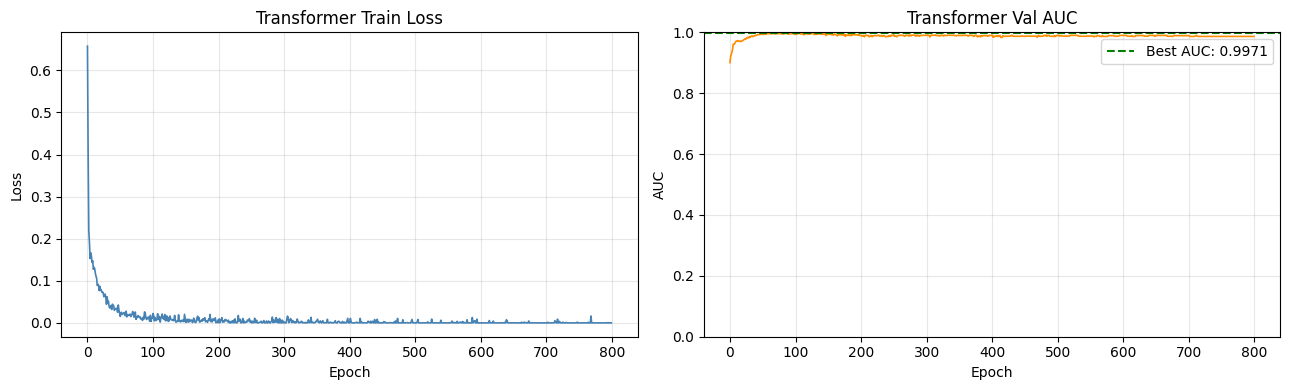

   Trans proba range : [0.0000  →  1.0000]
   Trans mean proba  : 0.0853
   Trans std  proba  : 0.2788
   Train AUC : 1.0000
   Test  AUC : 0.9866
✅ Transformer probabilities look healthy


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIX #4 (CLEANUP): Duplicate SeqDataset + build_real_weekly_sequences from
# the previous cell have been removed. This is the single canonical definition.
# FIX #1 (HIGH): seq_scaler is now fit only on train_idx_gnn rows.
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────
SEQ_LEN        = 8
FEAT_DIM       = 16

TRANS_D_MODEL      = 64
TRANS_NHEAD        = 4
TRANS_LAYERS       = 2
TRANS_FFN_DIM      = 256
TRANS_DROPOUT      = 0.4
TRANS_LR           = 3e-4
TRANS_WEIGHT_DECAY = 1e-3
TRANS_MAX_EPOCHS   = 800   # runs ALL epochs, no stopping

# ─────────────────────────────────────────────────────────────────────────────
# SeqDataset
# ─────────────────────────────────────────────────────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ─────────────────────────────────────────────────────────────────────────────
# Real weekly sequence builder
# ─────────────────────────────────────────────────────────────────────────────
def build_real_weekly_sequences(logon_df, file_df, email_df,
                                device_df, HTTPS_df,
                                all_users, train_indices, seq_len=8):
    # train_indices: indices of training users — scaler is fit ONLY on these rows
    all_dates = pd.concat([
        logon_df['date'], file_df['date'],
        email_df['date'], device_df['date']
    ]).dropna()

    global_start   = all_dates.min()
    global_end     = all_dates.max()
    total_days     = (global_end - global_start).days + 1
    week_size_days = total_days / seq_len

    print(f'  Date range : {global_start.date()} → {global_end.date()}')
    print(f'  Week size  : ~{week_size_days:.0f} days per window')

    def assign_weeks(df):
        df   = df.copy()
        days = (df['date'] - global_start).dt.days
        df['week'] = np.clip((days / week_size_days).astype(int), 0, seq_len - 1)
        df.loc[df['date'].isna(), 'week'] = -1
        return df

    logon_df  = assign_weeks(logon_df)
    file_df   = assign_weeks(file_df)
    email_df  = assign_weeks(email_df)
    device_df = assign_weeks(device_df)
    HTTPS_df  = assign_weeks(HTTPS_df)

    logon_grp  = logon_df.groupby(['user', 'week'])
    file_grp   = file_df.groupby(['user', 'week'])
    email_grp  = email_df.groupby(['user', 'week'])
    device_grp = device_df.groupby(['user', 'week'])
    https_grp  = HTTPS_df.groupby(['user', 'week'])

    FEAT_PER_WEEK = 16
    N             = len(all_users)
    X_seq         = np.zeros((N, seq_len, FEAT_PER_WEEK), dtype=np.float32)

    for i, user in enumerate(all_users):
        for w in range(seq_len):
            lg = logon_grp.get_group((user, w))  if (user, w) in logon_grp.groups  else None
            fl = file_grp.get_group((user, w))   if (user, w) in file_grp.groups   else None
            em = email_grp.get_group((user, w))  if (user, w) in email_grp.groups  else None
            dv = device_grp.get_group((user, w)) if (user, w) in device_grp.groups else None
            ht = https_grp.get_group((user, w))  if (user, w) in https_grp.groups  else None

            X_seq[i, w, :] = [
                len(lg)                        if lg is not None else 0,
                lg['is_after_hours'].sum()     if lg is not None else 0,
                lg['is_weekend'].sum()         if lg is not None else 0,
                lg['pc'].nunique()             if lg is not None else 0,
                len(fl)                        if fl is not None else 0,
                fl['is_after_hours'].sum()     if fl is not None else 0,
                len(em)                        if em is not None else 0,
                em['is_after_hours'].sum()     if em is not None else 0,
                em['has_attachment'].sum()     if em is not None else 0,
                em['to_count'].mean()          if em is not None else 0,
                len(dv)                        if dv is not None else 0,
                dv['is_after_hours'].sum()     if dv is not None else 0,
                len(ht)                        if ht is not None else 0,
                ht['is_cloud'].sum()           if ht is not None else 0,
                ht['is_job'].sum()             if ht is not None else 0,
                ht['is_leak'].sum()            if ht is not None else 0,
            ]

        if (i + 1) % 500 == 0:
            print(f'    Processed {i+1}/{N} users...')

    # ── FIX #1 (HIGH): fit scaler ONLY on train rows — prevents leakage ──────
    X_flat          = X_seq.reshape(-1, FEAT_PER_WEEK)
    train_flat_mask = np.zeros(N * seq_len, dtype=bool)
    for idx in train_indices:
        train_flat_mask[idx * seq_len:(idx + 1) * seq_len] = True
    seq_scaler  = StandardScaler()
    seq_scaler.fit(X_flat[train_flat_mask])   # fit on train rows only
    X_flat_norm = seq_scaler.transform(X_flat)  # transform all
    X_seq_norm  = X_flat_norm.reshape(N, seq_len, FEAT_PER_WEEK)

    print(f'  Sequence shape : {X_seq_norm.shape}')
    print(f'  Users          : {N}')
    print(f'  Feat/week      : {FEAT_PER_WEEK}')

    return X_seq_norm.astype(np.float32), FEAT_PER_WEEK, seq_scaler

# ─────────────────────────────────────────────────────────────────────────────
# Build sequences
# ─────────────────────────────────────────────────────────────────────────────
print('Building real weekly sequences...')

X_seq_real, FEAT_PER_WEEK, seq_scaler = build_real_weekly_sequences(
    logon_df      = logon_df,
    file_df       = file_df,
    email_df      = email_df,
    device_df     = device_df,
    HTTPS_df      = HTTPS_df,
    all_users     = features_df['user'].tolist(),
    train_indices = train_idx_gnn,  # FIX #1: pass train indices
    seq_len       = SEQ_LEN
)

FEAT_DIM  = FEAT_PER_WEEK
y_all_seq = features_df['label'].values

# ─────────────────────────────────────────────────────────────────────────────
# Split
# ─────────────────────────────────────────────────────────────────────────────
X_seq_train = X_seq_real[train_idx_gnn]
X_seq_test  = X_seq_real[test_idx_gnn]
y_seq_train = y_all_seq[train_idx_gnn]
y_seq_test  = y_all_seq[test_idx_gnn]

print(f'  Train : {X_seq_train.shape}  pos={y_seq_train.sum()}')
print(f'  Test  : {X_seq_test.shape}   pos={y_seq_test.sum()}')

# ─────────────────────────────────────────────────────────────────────────────
# SMOTE on train only
# ─────────────────────────────────────────────────────────────────────────────
X_flat_tr                   = X_seq_train.reshape(len(X_seq_train), -1)
sm                          = SMOTE(random_state=42, k_neighbors=min(5, int(y_seq_train.sum()) - 1))
X_flat_res, y_seq_train_res = sm.fit_resample(X_flat_tr, y_seq_train)
X_seq_train_res             = X_flat_res.reshape(-1, SEQ_LEN, FEAT_DIM)

print(f'  After SMOTE : {X_seq_train_res.shape}  pos={y_seq_train_res.sum()}')

# ─────────────────────────────────────────────────────────────────────────────
# DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
train_loader_seq = DataLoader(
    SeqDataset(X_seq_train_res, y_seq_train_res),
    batch_size=32, shuffle=True, drop_last=True   # batch=32 → more updates per epoch
)
test_loader_seq = DataLoader(
    SeqDataset(X_seq_test, y_seq_test),
    batch_size=256, shuffle=False
)

print(f'  Train batches : {len(train_loader_seq)}')
print(f'  Test  batches : {len(test_loader_seq)}')

# ─────────────────────────────────────────────────────────────────────────────
# Class-weighted loss
# ─────────────────────────────────────────────────────────────────────────────
_t_pos   = int(y_seq_train_res.sum())
_t_neg   = len(y_seq_train_res) - _t_pos
_t_ratio = (_t_neg / max(_t_pos, 1)) ** 0.5
criterion_trans = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, _t_ratio], dtype=torch.float32).to(device)
)
print(f'  Class weight — benign: 1.00  malicious: {_t_ratio:.2f}')

# ─────────────────────────────────────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────────────────────────────────────
class InsiderTransformer(nn.Module):
    def __init__(self, feat_dim, seq_len,
                 d_model    = TRANS_D_MODEL,
                 nhead      = TRANS_NHEAD,
                 num_layers = TRANS_LAYERS,
                 ffn_dim    = TRANS_FFN_DIM,
                 dropout    = TRANS_DROPOUT):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(feat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )
        self.pos_emb = nn.Embedding(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,
            activation      = 'gelu'
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers           = num_layers,
            enable_nested_tensor = False
        )

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x   = self.input_proj(x) + self.pos_emb(pos)
        x   = self.transformer(x)
        x   = self.norm(x)
        x   = x.mean(dim=1)
        return self.fc(self.dropout(x))

# ─────────────────────────────────────────────────────────────────────────────
# Model + Optimizer + Scheduler
# ─────────────────────────────────────────────────────────────────────────────
trans_model = InsiderTransformer(feat_dim=FEAT_DIM, seq_len=SEQ_LEN).to(device)

total_params = sum(p.numel() for p in trans_model.parameters() if p.requires_grad)
print(f'  Transformer trainable params: {total_params:,}')

optimizer_t = torch.optim.AdamW(
    trans_model.parameters(),
    lr           = TRANS_LR,
    weight_decay = TRANS_WEIGHT_DECAY
)

scheduler_t = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_t,
    T_max   = TRANS_MAX_EPOCHS,
    eta_min = 1e-6
)

# ─────────────────────────────────────────────────────────────────────────────
# Training loop — NO early stopping, runs all epochs, saves best checkpoint
# ─────────────────────────────────────────────────────────────────────────────
best_t_auc   = 0.0
best_t_state = None
trans_losses, trans_aucs = [], []

print('\n── Training ─────────────────────────────────────────')

for epoch in range(1, TRANS_MAX_EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    trans_model.train()
    ep_loss = 0.0

    for Xb, yb in train_loader_seq:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer_t.zero_grad()
        out  = trans_model(Xb)
        loss = criterion_trans(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trans_model.parameters(), 1.0)
        optimizer_t.step()
        ep_loss += loss.item()

    scheduler_t.step()

    # ── Validate ─────────────────────────────────────────────────────────────
    trans_model.eval()
    all_proba, all_true = [], []

    with torch.no_grad():
        for Xb, yb in test_loader_seq:
            proba = F.softmax(trans_model(Xb.to(device)), dim=1)[:, 1]
            all_proba.extend(proba.cpu().numpy())
            all_true.extend(yb.numpy())

    all_true  = np.array(all_true)
    all_proba = np.array(all_proba)

    t_auc    = roc_auc_score(all_true, all_proba) if len(np.unique(all_true)) >= 2 else 0.0
    avg_loss = ep_loss / len(train_loader_seq)

    trans_losses.append(avg_loss)
    trans_aucs.append(t_auc)

    # ── Always save best checkpoint — no stopping ─────────────────────────────
    if t_auc > best_t_auc:
        best_t_auc   = t_auc
        best_t_state = {k: v.clone() for k, v in trans_model.state_dict().items()}
        print(f'  ✨ New best at epoch {epoch:3d} | AUC: {best_t_auc:.4f}')

    if epoch % 20 == 0:
        current_lr = optimizer_t.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d} | Loss: {avg_loss:.4f} | '
              f'Val AUC: {t_auc:.4f} | '
              f'Best: {best_t_auc:.4f} | '
              f'LR: {current_lr:.6f}')

# ─────────────────────────────────────────────────────────────────────────────
# Restore best checkpoint
# ─────────────────────────────────────────────────────────────────────────────
trans_model.load_state_dict(best_t_state)
print(f'\n✅ Transformer done.  Best Val AUC: {best_t_auc:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(trans_losses, color='steelblue', linewidth=1.2)
ax1.set_title('Transformer Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(trans_aucs, color='darkorange', linewidth=1.2)
ax2.axhline(
    best_t_auc, color='green', linestyle='--', linewidth=1.5,
    label=f'Best AUC: {best_t_auc:.4f}'
)
ax2.set_title('Transformer Val AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase7_transformer_loss.png', dpi=100)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Collect probabilities for fusion
# ─────────────────────────────────────────────────────────────────────────────
trans_proba_test = all_proba

trans_model.eval()
all_train_p = []
with torch.no_grad():
    for Xb, _ in DataLoader(
        SeqDataset(X_seq_train, y_seq_train), batch_size=256
    ):
        p = F.softmax(trans_model(Xb.to(device)), dim=1)[:, 1]
        all_train_p.extend(p.cpu().numpy())
trans_proba_train = np.array(all_train_p)

# ─────────────────────────────────────────────────────────────────────────────
# Sanity checks
# ─────────────────────────────────────────────────────────────────────────────
print(f'   Trans proba range : [{trans_proba_test.min():.4f}  →  {trans_proba_test.max():.4f}]')
print(f'   Trans mean proba  : {trans_proba_test.mean():.4f}')
print(f'   Trans std  proba  : {trans_proba_test.std():.4f}')

train_auc_final = roc_auc_score(y_seq_train, trans_proba_train)
test_auc_final  = roc_auc_score(y_seq_test,  trans_proba_test)
print(f'   Train AUC : {train_auc_final:.4f}')
print(f'   Test  AUC : {test_auc_final:.4f}')

gap = train_auc_final - test_auc_final
if gap > 0.10:
    print(f'⚠️  Overfit gap {gap:.3f} — consider increasing TRANS_DROPOUT or TRANS_WEIGHT_DECAY')
elif trans_proba_test.std() < 0.01:
    print('⚠️  WARNING: Transformer outputting nearly identical scores for all users')
else:
    print('✅ Transformer probabilities look healthy')

  Fusion train : (800, 3)  pos=56
  Fusion test  : (200, 3)   pos=14
  XGB   — train mean: 0.1342  test mean: 0.1471  gap: 0.0129  ✅
  GNN   — train mean: 0.2340  test mean: 0.3468  gap: 0.1128  ✅
  Trans — train mean: 0.0712  test mean: 0.0853  gap: 0.0141  ✅
  After SMOTE  : (1488, 3)  pos=744
  Class weight — benign: 1.00  malicious: 1.00

── Fusion Training ──────────────────────────────────
  ✨ New best at epoch   1 | AUC: 0.9958
  ✨ New best at epoch   2 | AUC: 0.9962
  ✨ New best at epoch  41 | AUC: 0.9965
  Epoch  50 | Loss: 0.0100 | Val AUC: 0.9964 | Best: 0.9965
  ✨ New best at epoch  56 | AUC: 0.9969
  Epoch 100 | Loss: 0.0123 | Val AUC: 0.9958 | Best: 0.9969
  Epoch 150 | Loss: 0.0111 | Val AUC: 0.9958 | Best: 0.9969
  Epoch 200 | Loss: 0.0077 | Val AUC: 0.9958 | Best: 0.9969
  Epoch 250 | Loss: 0.0034 | Val AUC: 0.9958 | Best: 0.9969
  Epoch 300 | Loss: 0.0084 | Val AUC: 0.9958 | Best: 0.9969

✅ Fusion training done.  Best Val AUC: 0.9969

Fusion best threshold : 0.9996

F

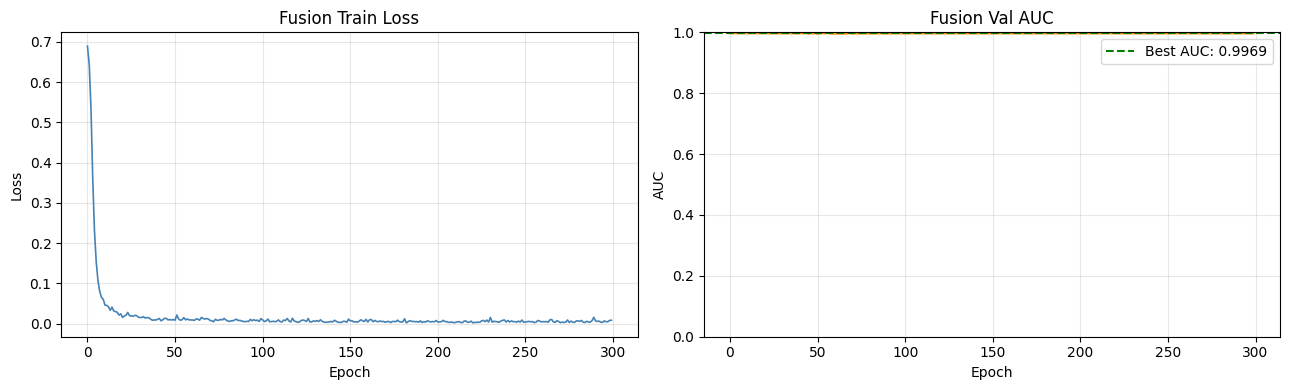

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Assemble fusion inputs — gnn_proba_train/test already clean from GNN cell
# ─────────────────────────────────────────────────────────────────────────────
fusion_X_train = np.stack([xgb_proba_train, gnn_proba_train, trans_proba_train], axis=1)
fusion_X_test  = np.stack([xgb_proba_test,  gnn_proba_test,  trans_proba_test],  axis=1)

print(f'  Fusion train : {fusion_X_train.shape}  pos={y_train.sum()}')
print(f'  Fusion test  : {fusion_X_test.shape}   pos={y_test.sum()}')

# ─────────────────────────────────────────────────────────────────────────────
# Sanity check
# ─────────────────────────────────────────────────────────────────────────────
for name, tr, te in [('XGB',   xgb_proba_train,   xgb_proba_test),
                     ('GNN',   gnn_proba_train,   gnn_proba_test),
                     ('Trans', trans_proba_train, trans_proba_test)]:
    gap = abs(te.mean() - tr.mean())
    print(f'  {name:5s} — train mean: {tr.mean():.4f}  test mean: {te.mean():.4f}  '
          f'gap: {gap:.4f}  {"✅" if gap <= 0.2 else "⚠️  LEAKING"}')

# ─────────────────────────────────────────────────────────────────────────────
# SMOTE on fusion train only
# ─────────────────────────────────────────────────────────────────────────────
sm_f           = SMOTE(random_state=42, k_neighbors=min(5, int(y_train.sum()) - 1))
fX_res, fy_res = sm_f.fit_resample(fusion_X_train, y_train)

print(f'  After SMOTE  : {fX_res.shape}  pos={fy_res.sum()}')

fX_tr = torch.tensor(fX_res,        dtype=torch.float32)
fy_tr = torch.tensor(fy_res,        dtype=torch.long)
fX_te = torch.tensor(fusion_X_test, dtype=torch.float32)
fy_te = torch.tensor(y_test,        dtype=torch.long)

fl_train = DataLoader(
    torch.utils.data.TensorDataset(fX_tr, fy_tr),
    batch_size=32, shuffle=True, drop_last=True
)

# ─────────────────────────────────────────────────────────────────────────────
# Own criterion — NOT criterion_gnn
# ─────────────────────────────────────────────────────────────────────────────
_f_pos       = int(fy_res.sum())
_f_neg       = len(fy_res) - _f_pos
_f_ratio     = (_f_neg / max(_f_pos, 1)) ** 0.5
criterion_fusion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, _f_ratio], dtype=torch.float32).to(device)
)
print(f'  Class weight — benign: 1.00  malicious: {_f_ratio:.2f}')

# ─────────────────────────────────────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────────────────────────────────────
class FusionMLP(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 8),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(8, 2)
        )
    def forward(self, x): return self.net(x)

fusion_model = FusionMLP(dropout=0.3).to(device)

opt_f = torch.optim.AdamW(
    fusion_model.parameters(), lr=5e-4, weight_decay=1e-3
)
scheduler_f = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_f, T_max=300, eta_min=1e-6
)

# ─────────────────────────────────────────────────────────────────────────────
# Training — no early stopping, all 300 epochs, saves best
# ─────────────────────────────────────────────────────────────────────────────
best_ft       = 0.0
best_fs       = None
fusion_aucs   = []
fusion_losses = []

print('\n── Fusion Training ──────────────────────────────────')

for epoch in range(1, 301):

    fusion_model.train()
    ep_loss = 0.0
    for Xb, yb in fl_train:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_f.zero_grad()
        loss = criterion_fusion(fusion_model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        opt_f.step()
        ep_loss += loss.item()

    scheduler_f.step()

    fusion_model.eval()
    with torch.no_grad():
        fp = F.softmax(fusion_model(fX_te.to(device)), dim=1)[:, 1].cpu().numpy()

    fa       = roc_auc_score(y_test, fp) if y_test.sum() > 0 else 0.0
    avg_loss = ep_loss / len(fl_train)
    fusion_aucs.append(fa)
    fusion_losses.append(avg_loss)

    if fa > best_ft:
        best_ft = fa
        best_fs = {k: v.clone() for k, v in fusion_model.state_dict().items()}
        print(f'  ✨ New best at epoch {epoch:3d} | AUC: {best_ft:.4f}')

    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {avg_loss:.4f} | '
              f'Val AUC: {fa:.4f} | Best: {best_ft:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Restore best
# ─────────────────────────────────────────────────────────────────────────────
fusion_model.load_state_dict(best_fs)
print(f'\n✅ Fusion training done.  Best Val AUC: {best_ft:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Final probabilities
# ─────────────────────────────────────────────────────────────────────────────
fusion_model.eval()
with torch.no_grad():
    fusion_proba_test = F.softmax(
        fusion_model(fX_te.to(device)), dim=1
    )[:, 1].cpu().numpy()

# ─────────────────────────────────────────────────────────────────────────────
# Optimal threshold via F1
# ─────────────────────────────────────────────────────────────────────────────
prec_f, rec_f, thr_f = precision_recall_curve(y_test, fusion_proba_test)
f1_f       = 2 * prec_f * rec_f / (prec_f + rec_f + 1e-8)
best_t     = float(thr_f[np.argmax(f1_f[:-1])])
best_preds = (fusion_proba_test >= best_t).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────────────────────────────────────
print(f'\nFusion best threshold : {best_t:.4f}')
print('\nFinal Classification Report (Fusion):')
print(classification_report(y_test, best_preds, target_names=['Benign', 'Malicious']))
print(f'ROC-AUC : {roc_auc_score(y_test, fusion_proba_test):.4f}')
print(f'AP      : {average_precision_score(y_test, fusion_proba_test):.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(fusion_losses, color='steelblue', linewidth=1.2)
ax1.set_title('Fusion Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

ax2.plot(fusion_aucs, color='darkorange', linewidth=1.2)
ax2.axhline(best_ft, color='green', linestyle='--', linewidth=1.5,
            label=f'Best AUC: {best_ft:.4f}')
ax2.set_title('Fusion Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC'); ax2.set_ylim(0, 1)
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase7_fusion.png', dpi=100)
plt.show()

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Leakage Diagnostic — updated for fixed variable names
# ─────────────────────────────────────────────────────────────────────────────
print('=== Leakage Diagnostic ===')

# GNN — now uses gnn_proba_train / gnn_proba_test (no more gnn_all_proba)
print(f'GNN   test  — mean: {gnn_proba_test.mean():.4f}   std: {gnn_proba_test.std():.4f}')
print(f'GNN   train — mean: {gnn_proba_train.mean():.4f}  std: {gnn_proba_train.std():.4f}')

# XGB
print(f'XGB   test  — mean: {xgb_proba_test.mean():.4f}   std: {xgb_proba_test.std():.4f}')
print(f'XGB   train — mean: {xgb_proba_train.mean():.4f}  std: {xgb_proba_train.std():.4f}')

# Transformer
print(f'Trans test  — mean: {trans_proba_test.mean():.4f}   std: {trans_proba_test.std():.4f}')
print(f'Trans train — mean: {trans_proba_train.mean():.4f}  std: {trans_proba_train.std():.4f}')

print(f'\nTrue positive rate in test : {y_test.mean():.4f}')
print(f'True positive rate in train: {y_train.mean():.4f}')

# ── Auto-check each model ─────────────────────────────────────────────────────
print('\n=== Gap Analysis ===')
for name, tr, te in [
    ('GNN',   gnn_proba_train,   gnn_proba_test),
    ('XGB',   xgb_proba_train,   xgb_proba_test),
    ('Trans', trans_proba_train, trans_proba_test),
]:
    gap = abs(te.mean() - tr.mean())
    status = '✅ clean' if gap <= 0.2 else '⚠️  LEAKING'
    print(f'  {name:5s} — train mean: {tr.mean():.4f}  '
          f'test mean: {te.mean():.4f}  '
          f'gap: {gap:.4f}  {status}')

=== Leakage Diagnostic ===
GNN   test  — mean: 0.3468   std: 0.1677
GNN   train — mean: 0.2340  std: 0.1404
XGB   test  — mean: 0.1471   std: 0.2560
XGB   train — mean: 0.1342  std: 0.2342
Trans test  — mean: 0.0853   std: 0.2788
Trans train — mean: 0.0712  std: 0.2565

True positive rate in test : 0.0700
True positive rate in train: 0.0700

=== Gap Analysis ===
  GNN   — train mean: 0.2340  test mean: 0.3468  gap: 0.1128  ✅ clean
  XGB   — train mean: 0.1342  test mean: 0.1471  gap: 0.0129  ✅ clean
  Trans — train mean: 0.0712  test mean: 0.0853  gap: 0.0141  ✅ clean


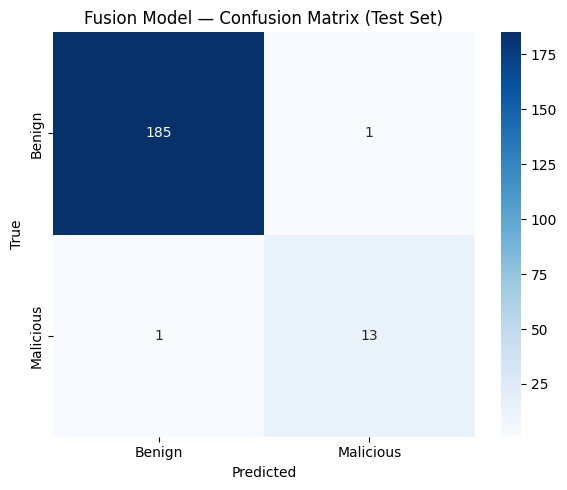

In [16]:
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malicious'],
            yticklabels=['Benign','Malicious'])
plt.title('Fusion Model — Confusion Matrix (Test Set)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('phase8_confusion_matrix.png', dpi=100)
plt.show()


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Risk score table for ALL users
# Uses real weekly sequences — consistent with how transformer was trained
# ─────────────────────────────────────────────────────────────────────────────

# ── XGB probas for all users ──────────────────────────────────────────────────
# FIX #2 (CRITICAL): Use `scaler` (XGB scaler), NOT `graph_scaler` (GNN scaler)
xgb_all_proba = xgb_model.predict_proba(
    scaler.transform(features_df[feature_cols].values.astype(np.float32))
)[:, 1]

# ── GNN probas for all users — MLP path for test, graph path for train ────────
gnn_model.eval()
with torch.no_grad():
    # Train nodes — full graph
    out_train    = gnn_model(graph_data.x, graph_data.edge_index)
    proba_all_gnn = F.softmax(out_train, dim=1)[:, 1].cpu().numpy()

    # Override test node scores with clean MLP path
    out_test     = gnn_model.forward_mlp(graph_data.x[test_idx_gnn])
    proba_all_gnn[test_idx_gnn] = F.softmax(out_test, dim=1)[:, 1].cpu().numpy()

gnn_all_proba = proba_all_gnn

# ── Transformer probas for all users — real weekly sequences ──────────────────
print('Building real weekly sequences for all users...')
X_seq_all, _, _ = build_real_weekly_sequences(
    logon_df      = logon_df,
    file_df       = file_df,
    email_df      = email_df,
    device_df     = device_df,
    HTTPS_df      = HTTPS_df,
    all_users     = features_df['user'].tolist(),
    train_indices = train_idx_gnn,  # FIX #1: consistent with training
    seq_len       = SEQ_LEN
)

trans_model.eval()
all_seqT    = torch.tensor(X_seq_all, dtype=torch.float32)
trans_all_p = []
with torch.no_grad():
    for i in range(0, len(all_seqT), 256):
        p = F.softmax(trans_model(all_seqT[i:i+256].to(device)), dim=1)[:, 1]
        trans_all_p.extend(p.cpu().numpy())
trans_all_proba = np.array(trans_all_p)

# ── Fusion probas for all users ───────────────────────────────────────────────
fusion_model.eval()
fusion_all_X = torch.tensor(
    np.stack([xgb_all_proba, gnn_all_proba, trans_all_proba], axis=1),
    dtype=torch.float32
)
with torch.no_grad():
    fusion_all_proba = F.softmax(
        fusion_model(fusion_all_X.to(device)), dim=1
    )[:, 1].cpu().numpy()

# ── Build risk table ──────────────────────────────────────────────────────────
risk_df = features_df[['user', 'label']].copy()
risk_df['xgb_score']        = xgb_all_proba
risk_df['gnn_score']        = gnn_all_proba
risk_df['trans_score']      = trans_all_proba
risk_df['fusion_score']     = fusion_all_proba
risk_df['risk_pct']         = (fusion_all_proba * 100).round(1)
risk_df['predicted_threat'] = (fusion_all_proba >= best_t).astype(int)
risk_df['split']            = 'train'
risk_df.loc[risk_df.index[test_idx_gnn], 'split'] = 'test'

risk_df = risk_df.sort_values('risk_pct', ascending=False)
risk_df.to_csv('risk_scores.csv', index=False)

print('✅ Risk scores saved to risk_scores.csv')
print(f'\nTop 20 highest-risk users:')
print(risk_df.head(20)[['user', 'risk_pct', 'predicted_threat', 'label', 'split']].to_string(index=False))

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f'\n=== Score Summary ===')
for name, arr in [('XGB',    xgb_all_proba),
                  ('GNN',    gnn_all_proba),
                  ('Trans',  trans_all_proba),
                  ('Fusion', fusion_all_proba)]:
    print(f'  {name:6s} — mean: {arr.mean():.4f}  std: {arr.std():.4f}  '
          f'range: [{arr.min():.4f} → {arr.max():.4f}]')

Building real weekly sequences for all users...
  Date range : 2010-01-02 → 2011-05-17
  Week size  : ~62 days per window
    Processed 500/1000 users...
    Processed 1000/1000 users...
  Sequence shape : (1000, 8, 16)
  Users          : 1000
  Feat/week      : 16
✅ Risk scores saved to risk_scores.csv

Top 20 highest-risk users:
   user  risk_pct  predicted_threat  label split
AAF0535     100.0                 1      1 train
FTM0406     100.0                 1      1  test
WDD0366     100.0                 1      1 train
IKR0401     100.0                 1      1 train
AJR0932     100.0                 1      1  test
MAS0025     100.0                 1      1 train
ABC0174     100.0                 1      1 train
IUB0565     100.0                 1      1 train
DIB0285     100.0                 1      1 train
LJR0523     100.0                 1      1 train
BDV0168     100.0                 1      1 train
BTL0226     100.0                 1      1 train
NWT0098     100.0             

In [18]:
from google.colab import drive
import os, pickle, json, torch
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/insider_threat/GNN-Transformer-XGboost'
os.makedirs(SAVE_PATH, exist_ok=True)
print('Saving models to:', SAVE_PATH)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_model.save_model(f'{SAVE_PATH}/xgb_model.json')
print('✅ XGBoost saved')

# ── Scalers — all 3, one per model ───────────────────────────────────────────
with open(f'{SAVE_PATH}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)              # XGBoost input scaler

with open(f'{SAVE_PATH}/graph_scaler.pkl', 'wb') as f:
    pickle.dump(graph_scaler, f)        # GNN node feature scaler

with open(f'{SAVE_PATH}/seq_scaler.pkl', 'wb') as f:
    pickle.dump(seq_scaler, f)          # Transformer sequence scaler
print('✅ All 3 scalers saved')

# ── PyTorch model weights ─────────────────────────────────────────────────────
torch.save(gnn_model.state_dict(),    f'{SAVE_PATH}/gnn_model.pt')
torch.save(trans_model.state_dict(),  f'{SAVE_PATH}/transformer_model.pt')
torch.save(fusion_model.state_dict(), f'{SAVE_PATH}/fusion_model.pt')
print('✅ GNN, Transformer, Fusion weights saved')

# ── Model architecture configs — needed to rebuild before loading weights ─────
model_configs = {
    'gnn': {
        'in_dim'     : int(graph_data.x.shape[1]),
        'hidden_dim' : GNN_HIDDEN_DIM,
        'out_dim'    : 2,
        'heads'      : GNN_HEADS,
        'dropout'    : GNN_DROPOUT,
    },
    'transformer': {
        'feat_dim'   : FEAT_DIM,
        'seq_len'    : SEQ_LEN,
        'd_model'    : TRANS_D_MODEL,
        'nhead'      : TRANS_NHEAD,
        'num_layers' : TRANS_LAYERS,
        'ffn_dim'    : TRANS_FFN_DIM,
        'dropout'    : TRANS_DROPOUT,
    },
    'fusion': {
        'dropout'    : 0.3,
    }
}
with open(f'{SAVE_PATH}/model_configs.json', 'w') as f:
    json.dump(model_configs, f, indent=2)
print('✅ Model architecture configs saved')

# ── Feature and user metadata ─────────────────────────────────────────────────
with open(f'{SAVE_PATH}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

with open(f'{SAVE_PATH}/user2idx.json', 'w') as f:
    json.dump(user2idx, f)
print('✅ Feature cols and user index saved')

# ── Thresholds ────────────────────────────────────────────────────────────────
with open(f'{SAVE_PATH}/thresholds.json', 'w') as f:
    json.dump({
        'xgb'   : float(best_thresh),
        'fusion': float(best_t)
    }, f, indent=2)
print('✅ Thresholds saved')

# ── Graph edge index ──────────────────────────────────────────────────────────
torch.save(graph_data.edge_index.cpu(), f'{SAVE_PATH}/graph_edge_index.pt')
print('✅ Graph edge index saved')

# ── Sequence config ───────────────────────────────────────────────────────────
with open(f'{SAVE_PATH}/seq_config.json', 'w') as f:
    json.dump({
        'SEQ_LEN'       : SEQ_LEN,
        'FEAT_DIM'      : FEAT_DIM,
        'FEAT_PER_WEEK' : FEAT_PER_WEEK,
    }, f, indent=2)
print('✅ Sequence config saved')

print('\n✅ All models saved — ready for inference on any dataset')
!ls -lh {SAVE_PATH}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving models to: /content/drive/MyDrive/insider_threat/GNN-Transformer-XGboost
✅ XGBoost saved
✅ All 3 scalers saved
✅ GNN, Transformer, Fusion weights saved
✅ Model architecture configs saved
✅ Feature cols and user index saved
✅ Thresholds saved
✅ Graph edge index saved
✅ Sequence config saved

✅ All models saved — ready for inference on any dataset
total 1.5M
-rw------- 1 root root  596 Mar 20 08:06 feature_cols.json
-rw------- 1 root root 6.9K Mar 20 08:06 fusion_model.pt
-rw------- 1 root root 131K Mar 20 08:06 gnn_model.pt
-rw------- 1 root root 779K Mar 20 08:06 graph_edge_index.pt
-rw------- 1 root root 1.2K Mar 20 08:06 graph_scaler.pkl
-rw------- 1 root root  306 Mar 20 08:06 model_configs.json
-rw------- 1 root root 1.2K Mar 20 08:06 scaler.pkl
-rw------- 1 root root   59 Mar 20 08:06 seq_config.json
-rw------- 1 root root  834 Mar 20 08:06 seq_sc

In [19]:
!zip -r insider_threat_system.zip risk_scores.csv eda_overview.png \
    phase5_xgb_importance.png phase6_gnn_loss.png \
    phase7_transformer_loss.png phase8_confusion_matrix.png

from google.colab import files
files.download('insider_threat_system.zip')
print('✅ Download started!')


  adding: risk_scores.csv (deflated 67%)
  adding: eda_overview.png (deflated 25%)
  adding: phase5_xgb_importance.png (deflated 20%)
  adding: phase6_gnn_loss.png (deflated 11%)
  adding: phase7_transformer_loss.png (deflated 13%)
  adding: phase8_confusion_matrix.png (deflated 13%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


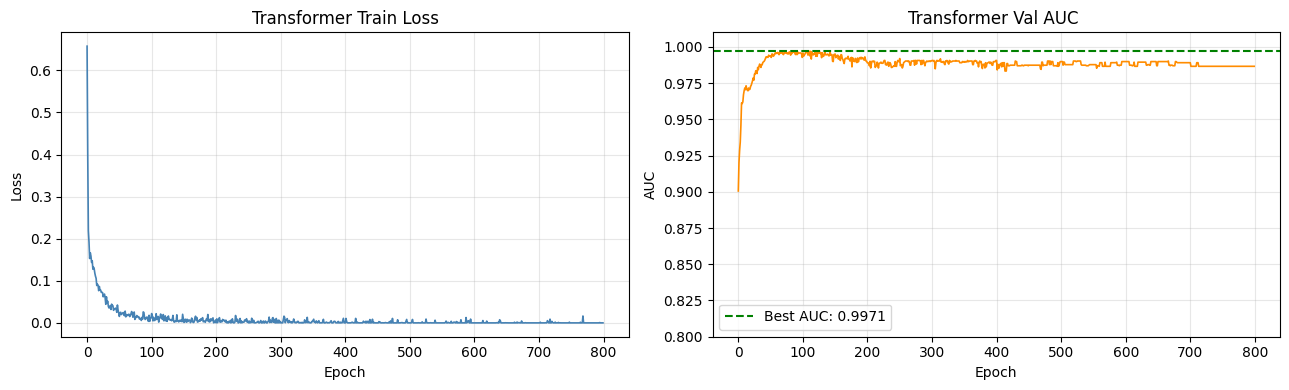

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Re-Plotting only (Run this if training variables are still in memory)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Loss
ax1.plot(trans_losses, color='steelblue', linewidth=1.2)
ax1.set_title('Transformer Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

# Plot 2: AUC (Zoomed in)
ax2.plot(trans_aucs, color='darkorange', linewidth=1.2)
ax2.axhline(
    best_t_auc, color='green', linestyle='--', linewidth=1.5,
    label=f'Best AUC: {best_t_auc:.4f}'
)
ax2.set_title('Transformer Val AUC ')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')

# The requested change: zoom to 0.8 and above
ax2.set_ylim(0.8, 1.01)

ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

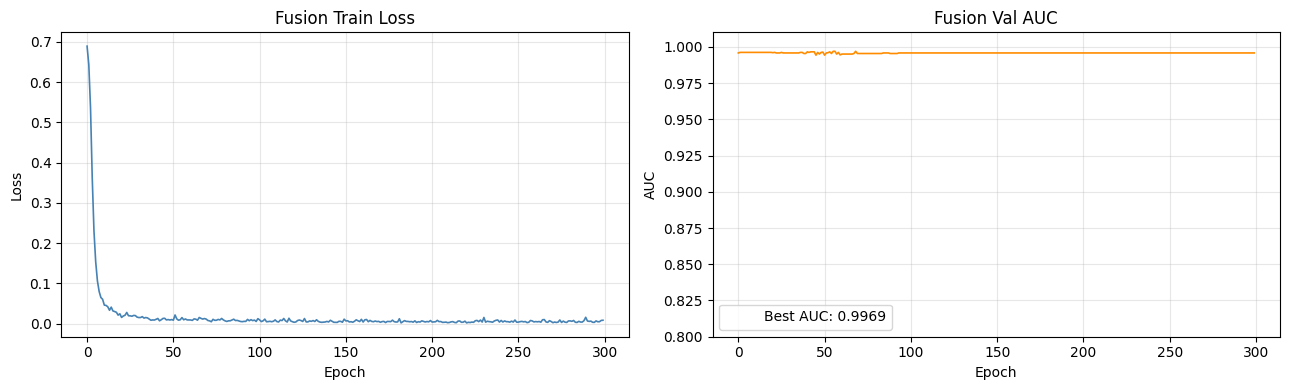

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Re-Plotting Fusion (Run this if fusion_losses/aucs are in memory)
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Fusion Loss
ax1.plot(fusion_losses, color='steelblue', linewidth=1.2)
ax1.set_title('Fusion Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

# Plot 2: Fusion AUC (Zoomed 0.8 - 1.01)
ax2.plot(fusion_aucs, color='darkorange', linewidth=1.2)
ax2.axhline(
    best_ft, color='green', linestyle='', linewidth=1.5,
    label=f'Best AUC: {best_ft:.4f}'
)
ax2.set_title('Fusion Val AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')

# Change: Start scale at 0.8
ax2.set_ylim(0.8, 1.01)

ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase7_fusion.png', dpi=100)
plt.show()

In [20]:
# # SECTION: METHODOLOGY
# Details of   GNN Transformer XGBoost
# (In the form of Flowchart, Algorithm, Pseudocode, System Architecture)
# Add Few formuals which was used by this methodology.

In [21]:
# # SECTION: EXPERIMENTAL SETUP,
# Experimental Setup 1:
# 1) LSTM Autoencoder How it is implemented and what were the results
# 2) GNN Transoformer XGBoost: How and results. (graphs, tables, numbes)
# Exoperimental Setup 2:
# # SECTION: CONCLUSION
# Discuss the both results independetly.
# Compare 1 with 2.
# Prove how 2 experiment is better then the first.
